# 08 Peak-Hour Prediction

Predict each building's daily peak electricity hour using building attributes, weather conditions, calendar information, and the previous day's 24 hourly meter readings.

The EDA finding that 14:00 is the most common peak hour becomes the fixed benchmark. A useful model must outperform always predicting 14:00.

Target building-days must contain all 24 hours and more than one unique meter reading. Flat and incomplete target days are excluded because they do not have a reliable unique peak. The chronological test dataset remains untouched in this notebook.

## Setup

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
modeling_dir = project_root / "data" / "processed" / "modeling"
reports_dir = project_root / "reports"
figures_dir = project_root / "figures"
reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

## Build One Row per Building-Day

In [2]:
hourly_columns = [
    "building_id",
    "timestamp",
    "meter_reading",
    "site_id",
    "primary_use",
    "square_feet",
    "year_built",
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_speed",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
]


def build_daily_table(path: Path, split_name: str) -> pd.DataFrame:
    hourly = pd.read_parquet(path, columns=hourly_columns)
    hourly["date"] = hourly["timestamp"].dt.normalize()
    hourly = hourly.sort_values(["building_id", "timestamp"]).reset_index(
        drop=True
    )

    grouped = hourly.groupby(["building_id", "date"], observed=True)
    daily = grouped.agg(
        hourly_records=("hour", "count"),
        unique_hours=("hour", "nunique"),
        unique_readings=("meter_reading", "nunique"),
        daily_mean=("meter_reading", "mean"),
        daily_max=("meter_reading", "max"),
        daily_min=("meter_reading", "min"),
        daily_std=("meter_reading", "std"),
        site_id=("site_id", "first"),
        primary_use=("primary_use", "first"),
        square_feet=("square_feet", "first"),
        year_built=("year_built", "first"),
        day_of_week=("day_of_week", "first"),
        month=("month", "first"),
        is_weekend=("is_weekend", "first"),
        temperature_mean=("air_temperature", "mean"),
        temperature_max=("air_temperature", "max"),
        temperature_min=("air_temperature", "min"),
        dew_temperature_mean=("dew_temperature", "mean"),
        cloud_coverage_mean=("cloud_coverage", "mean"),
        precipitation_total=("precip_depth_1_hr", "sum"),
        sea_level_pressure_mean=("sea_level_pressure", "mean"),
        wind_speed_mean=("wind_speed", "mean"),
        wind_speed_max=("wind_speed", "max"),
    ).reset_index()

    peak_indices = grouped["meter_reading"].idxmax()
    peaks = hourly.loc[
        peak_indices.to_numpy(),
        ["building_id", "date", "hour"],
    ].rename(columns={"hour": "peak_hour"})

    profile = hourly.pivot_table(
        index=["building_id", "date"],
        columns="hour",
        values="meter_reading",
        aggfunc="first",
    ).reindex(columns=range(24))
    profile.columns = [f"reading_h{hour:02d}" for hour in range(24)]
    profile = profile.reset_index()

    daily = daily.merge(
        peaks,
        on=["building_id", "date"],
        how="left",
        validate="one_to_one",
    ).merge(
        profile,
        on=["building_id", "date"],
        how="left",
        validate="one_to_one",
    )
    daily["split"] = split_name
    return daily


train_daily = build_daily_table(
    modeling_dir / "model_train.parquet",
    "train",
)
validation_daily = build_daily_table(
    modeling_dir / "model_validation.parquet",
    "validation",
)

daily_data = (
    pd.concat([train_daily, validation_daily], ignore_index=True)
    .sort_values(["building_id", "date"])
    .reset_index(drop=True)
)

pd.DataFrame(
    {
        "split": ["train", "validation"],
        "building_days": [len(train_daily), len(validation_daily)],
    }
)

,split,building_days
0,train,350675
1,validation,77070


## Add Leakage-Safe Historical Features

In [3]:
reading_columns = [f"reading_h{hour:02d}" for hour in range(24)]
historical_source_columns = [
    "daily_mean",
    "daily_max",
    "daily_min",
    "daily_std",
    "peak_hour",
    "hourly_records",
] + reading_columns

building_groups = daily_data.groupby("building_id", observed=True)
daily_data["previous_date"] = building_groups["date"].shift(1)
consecutive_previous_day = (
    daily_data["date"] - daily_data["previous_date"]
) == pd.Timedelta(days=1)

for column in historical_source_columns:
    historical_column = f"previous_{column}"
    daily_data[historical_column] = building_groups[column].shift(1)
    daily_data.loc[~consecutive_previous_day, historical_column] = np.nan

daily_data["previous_day_complete"] = (
    daily_data["previous_hourly_records"] == 24
).astype("int8")
daily_data["previous_peak_sin"] = np.sin(
    2 * np.pi * daily_data["previous_peak_hour"] / 24
)
daily_data["previous_peak_cos"] = np.cos(
    2 * np.pi * daily_data["previous_peak_hour"] / 24
)
daily_data["log_square_feet"] = np.log1p(daily_data["square_feet"])
daily_data["building_age"] = (
    2016 - daily_data["year_built"]
).clip(lower=0)

daily_data["eligible_target_day"] = (
    (daily_data["hourly_records"] == 24)
    & (daily_data["unique_hours"] == 24)
    & (daily_data["unique_readings"] > 1)
)

eligibility_summary = (
    daily_data.groupby("split", observed=True)["eligible_target_day"]
    .agg(["count", "sum", "mean"])
    .rename(
        columns={
            "count": "all_building_days",
            "sum": "eligible_building_days",
            "mean": "eligible_fraction",
        }
    )
)
eligibility_summary

,all_building_days,eligible_building_days,eligible_fraction
split,,,
train,350675,309206,0.881745
validation,77070,70390,0.913326


## Prepare Training and Validation Data

In [4]:
previous_profile_features = [
    f"previous_reading_h{hour:02d}" for hour in range(24)
]
numeric_features = [
    "log_square_feet",
    "building_age",
    "day_of_week",
    "month",
    "is_weekend",
    "temperature_mean",
    "temperature_max",
    "temperature_min",
    "dew_temperature_mean",
    "cloud_coverage_mean",
    "precipitation_total",
    "sea_level_pressure_mean",
    "wind_speed_mean",
    "wind_speed_max",
    "previous_daily_mean",
    "previous_daily_max",
    "previous_daily_min",
    "previous_daily_std",
    "previous_peak_sin",
    "previous_peak_cos",
    "previous_day_complete",
] + previous_profile_features
categorical_features = ["site_id", "primary_use"]
feature_columns = numeric_features + categorical_features
target_column = "peak_hour"

eligible_data = daily_data[daily_data["eligible_target_day"]].copy()
train_data = eligible_data[eligible_data["split"] == "train"].copy()
validation_data = eligible_data[
    eligible_data["split"] == "validation"
].copy()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                            dtype=np.float32,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

X_train = preprocessor.fit_transform(train_data[feature_columns]).astype(
    "float32"
)
X_validation = preprocessor.transform(
    validation_data[feature_columns]
).astype("float32")
y_train = train_data[target_column].to_numpy(dtype="int8")
y_validation = validation_data[target_column].to_numpy(dtype="int8")

training_peak_mode = int(pd.Series(y_train).mode().iloc[0])

pd.Series(
    {
        "training_building_days": len(train_data),
        "validation_building_days": len(validation_data),
        "features_after_encoding": X_train.shape[1],
        "training_peak_mode": f"{training_peak_mode:02d}:00",
    }
)

training_building_days      309206
validation_building_days     70390
features_after_encoding         77
training_peak_mode           14:00
dtype: object

## Peak-Timing Metrics

In [5]:
def peak_metrics(
    model_name: str,
    y_true: np.ndarray,
    predictions: np.ndarray,
    fit_seconds: float,
    top_3_accuracy: float = np.nan,
) -> dict:
    absolute_difference = np.abs(y_true - predictions)
    circular_error = np.minimum(
        absolute_difference,
        24 - absolute_difference,
    )
    return {
        "model": model_name,
        "exact_peak_accuracy": (circular_error == 0).mean(),
        "within_1_hour_accuracy": (circular_error <= 1).mean(),
        "within_2_hours_accuracy": (circular_error <= 2).mean(),
        "mean_peak_hour_error": circular_error.mean(),
        "median_peak_hour_error": np.median(circular_error),
        "macro_f1": f1_score(y_true, predictions, average="macro"),
        "top_3_accuracy": top_3_accuracy,
        "fit_seconds": fit_seconds,
    }


def calculate_top_3_accuracy(
    model,
    features: np.ndarray,
    target: np.ndarray,
) -> float:
    probabilities = model.predict_proba(features)
    top_3_indices = np.argpartition(probabilities, -3, axis=1)[:, -3:]
    top_3_classes = model.classes_[top_3_indices]
    return np.any(top_3_classes == target[:, None], axis=1).mean()

## Train the Peak-Hour Models

In [6]:
peak_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1_000,
        tol=1e-3,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Histogram Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=60,
        learning_rate=0.10,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    ),
}

metric_rows = []
validation_predictions = {}

baseline_predictions = np.full_like(y_validation, fill_value=14)
metric_rows.append(
    peak_metrics(
        "Always predict 14:00",
        y_validation,
        baseline_predictions,
        fit_seconds=0.0,
    )
)
validation_predictions["Always predict 14:00"] = baseline_predictions

for model_name, model in peak_models.items():
    print(f"Training {model_name}...")
    start = perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = perf_counter() - start
    predictions = model.predict(X_validation).astype("int8")
    top_3_accuracy = calculate_top_3_accuracy(
        model,
        X_validation,
        y_validation,
    )
    metric_rows.append(
        peak_metrics(
            model_name,
            y_validation,
            predictions,
            fit_seconds,
            top_3_accuracy,
        )
    )
    validation_predictions[model_name] = predictions

peak_validation_metrics = (
    pd.DataFrame(metric_rows)
    .sort_values(
        ["within_1_hour_accuracy", "exact_peak_accuracy"],
        ascending=False,
    )
    .reset_index(drop=True)
)
peak_validation_metrics.to_csv(
    reports_dir / "peak_hour_validation_metrics.csv",
    index=False,
)

peak_validation_metrics

Training Logistic Regression...
Training Random Forest...
Training Histogram Gradient Boosting...


,model,exact_peak_accuracy,within_1_hour_accuracy,within_2_hours_accuracy,mean_peak_hour_error,median_peak_hour_error,macro_f1,top_3_accuracy,fit_seconds
0,Random Forest,0.212317,0.474073,0.632917,2.607501,2.0,0.192486,0.495965,68.686333
1,Histogram Gradient Boosting,0.208936,0.465847,0.615585,2.739068,2.0,0.184505,0.488464,66.580073
2,Logistic Regression,0.155249,0.414775,0.585524,2.939906,2.0,0.100201,0.423583,19.390602
3,Always predict 14:00,0.100483,0.288209,0.437662,3.775210,3.0,0.007609,NaN,0.000000


## Compare Models With the 14:00 Baseline

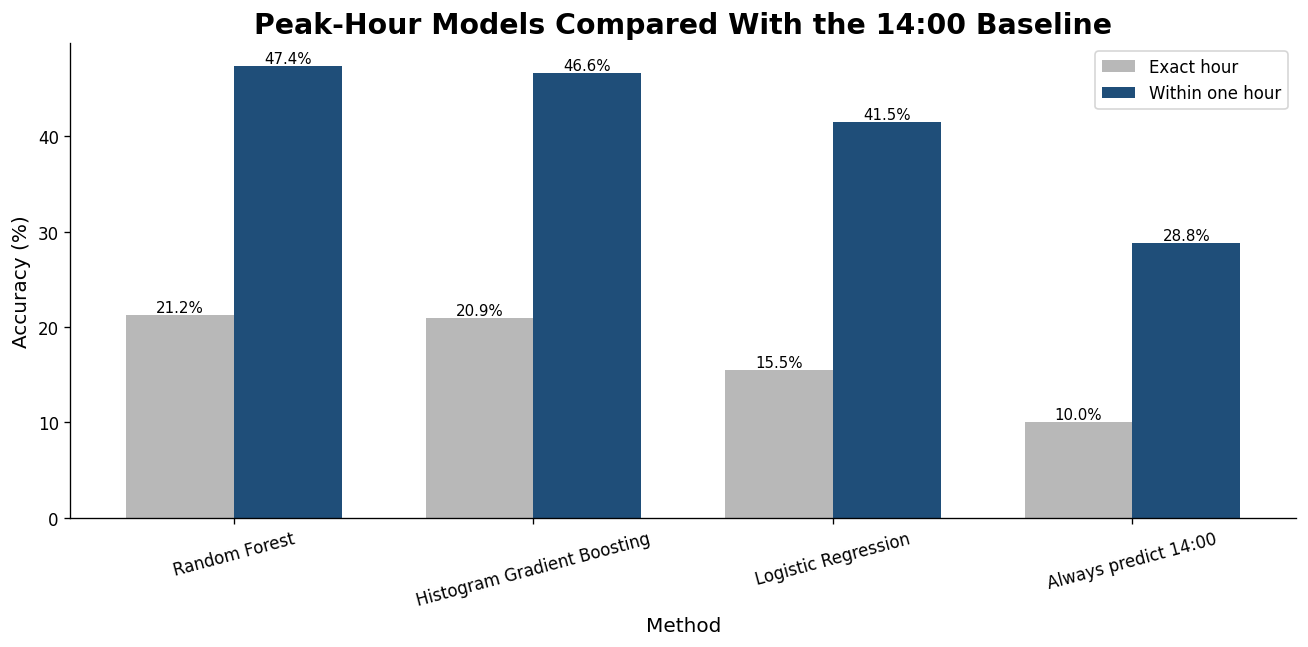

In [7]:
plot_data = peak_validation_metrics.sort_values(
    "within_1_hour_accuracy",
    ascending=False,
).reset_index(drop=True)
x_positions = np.arange(len(plot_data))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(11, 5.5), dpi=120)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

exact_bars = ax.bar(
    x_positions - bar_width / 2,
    plot_data["exact_peak_accuracy"] * 100,
    width=bar_width,
    color="#b8b8b8",
    label="Exact hour",
)
within_bars = ax.bar(
    x_positions + bar_width / 2,
    plot_data["within_1_hour_accuracy"] * 100,
    width=bar_width,
    color="#1f4e79",
    label="Within one hour",
)

ax.set_title("Peak-Hour Models Compared With the 14:00 Baseline", fontsize=17, weight="bold")
ax.set_xlabel("Method", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_data["model"], rotation=15)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

for bars in [exact_bars, within_bars]:
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
fig.savefig(
    figures_dir / "peak_hour_model_comparison.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Peak-Hour Distribution Check

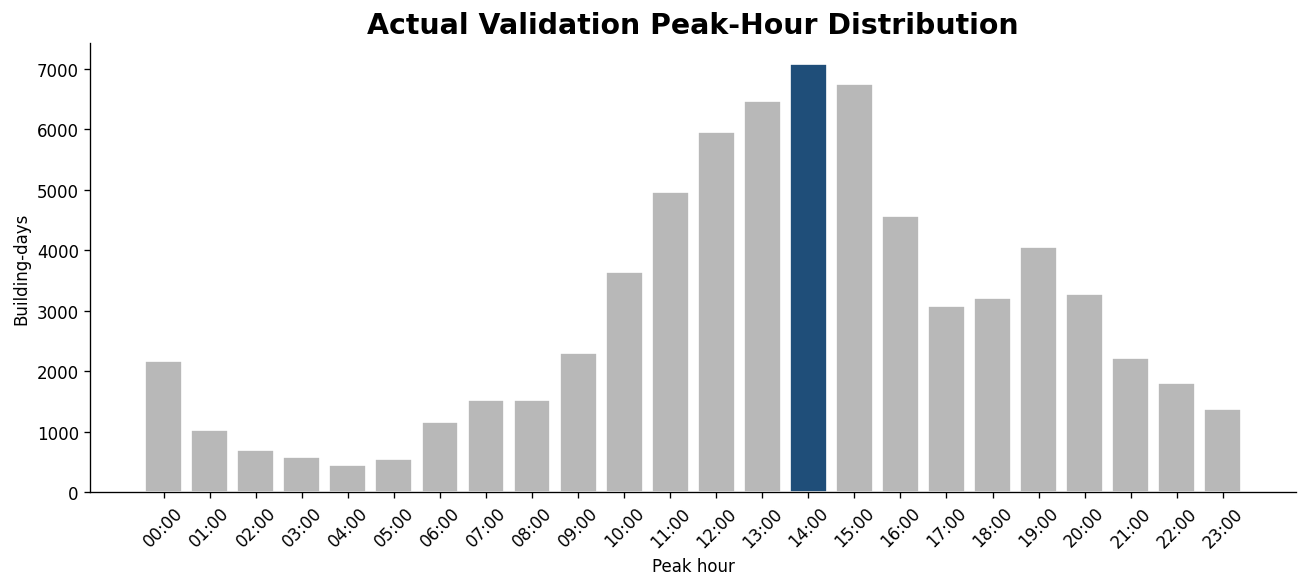

In [8]:
actual_distribution = (
    pd.Series(y_validation)
    .value_counts()
    .sort_index()
    .reindex(range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 5), dpi=120)
colors = ["#1f4e79" if hour == 14 else "#b8b8b8" for hour in range(24)]
ax.bar(range(24), actual_distribution.values, color=colors, edgecolor="white")
ax.set_title("Actual Validation Peak-Hour Distribution", fontsize=17, weight="bold")
ax.set_xlabel("Peak hour")
ax.set_ylabel("Building-days")
ax.set_xticks(range(24))
ax.set_xticklabels([f"{hour:02d}:00" for hour in range(24)], rotation=45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
plt.tight_layout()
fig.savefig(
    figures_dir / "validation_peak_hour_distribution.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Interpretation Rule

The preferred model must outperform always predicting 14:00, especially for within-one-hour accuracy and mean circular hour error. Current-day weather summaries are treated as proxies for day-ahead weather forecasts. Preserve the chronological test dataset for one final evaluation after the modeling design is selected.